In [1]:
import numpy as np  # for matrix operations
import pandas as pd # for data loading
import matplotlib.pyplot as plt  # for plotting
from models import *  ## for algorithms
import seaborn as sns  # for plotting
sns.set_theme()

# Part 1

I will refer the feature matrix as `X` and dependent variable vector as `y` 

In [2]:
# Loading the data
training_data=pd.read_csv('FMLA1Q1Data_train.csv', header=None)
training_data.head()
X, y=training_data.drop(labels=2, axis=1), training_data[2]

Analyticial Solution is given by the below formula

$w_{ML}=(X^TX)^{-1}X^TY$

The `analytical_solution()` is the method that calculates the analytical solution.

In [3]:
reg=OLS()
reg.fit(X, y)
w_ml=reg.coef_
w_ml, mse(y, reg.predict(X))

(array([1.76570568, 3.5215898 , 9.89400832]), 123.36485997994839)

In [4]:
gd=GradientDescent(step_size=0.0001, iterations=200)
gd.fit(X, y, w_ml=w_ml)
gd.coef_

array([1.76570567, 3.5215898 , 9.89400831])

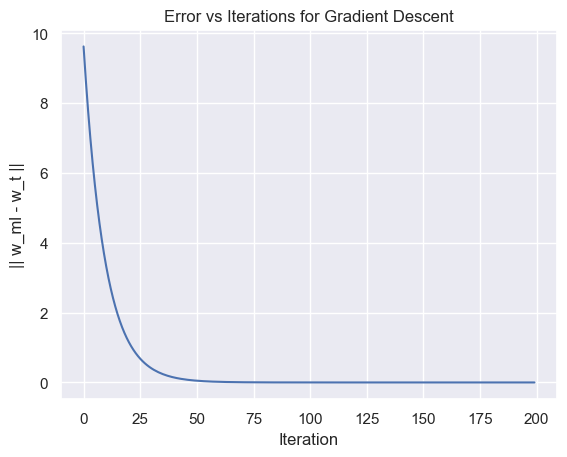

In [5]:
plt.plot(range(gd.actual_iterations), gd.errors)
plt.xlabel('Iteration')
plt.ylabel('|| w_ml - w_t ||')
plt.title('Error vs Iterations for Gradient Descent')
plt.show()

In [6]:
sgd=StochasticGradientDescent(step_size=None, iterations=10000)
sgd.fit(X, y, w_ml=w_ml)
sgd.coef_

array([1.7647203 , 3.52233852, 9.89444581])

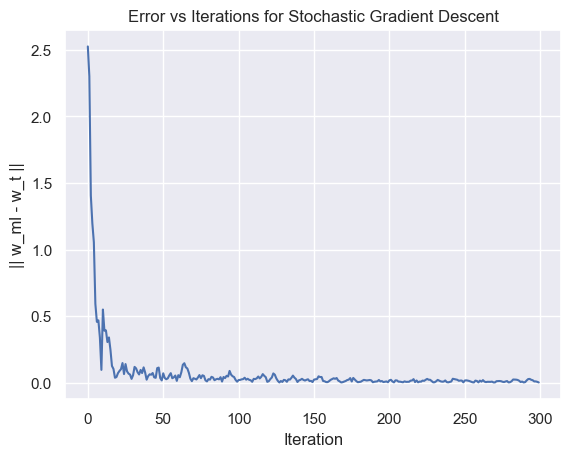

In [7]:
plt.plot(range(sgd.actual_iterations)[:300], sgd.errors[:300])
plt.xlabel('Iteration')
plt.ylabel('|| w_ml - w_t ||')
plt.title('Error vs Iterations for Stochastic Gradient Descent')
plt.show()

In [7]:
alphas = np.linspace(2, 4, 30)
errors=[]
for alpha in alphas:
    errors.append(cross_validate(X, y, RidgeGD(alpha, 0.0001, 1000), 0.2, random_seed=5))

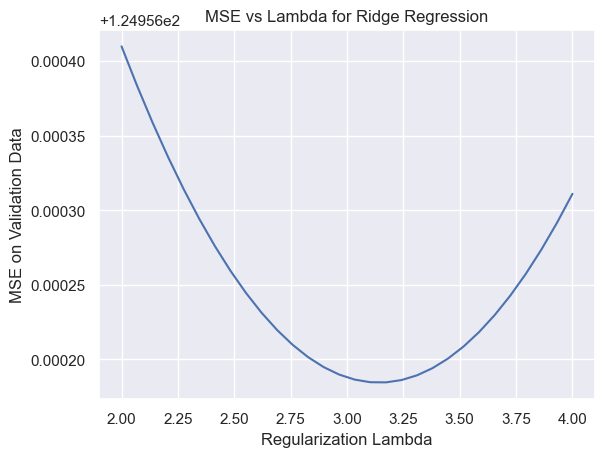

In [8]:
plt.plot(alphas, errors)
plt.xlabel('Regularization Lambda')
plt.ylabel('MSE on Validation Data')
plt.title('MSE vs Lambda for Ridge Regression')
plt.show()

In [6]:
np.argmin(errors)

17

In [7]:
np.min(errors), errors[17], alphas[17]

(124.9561846426997, 124.9561846426997, 3.1724137931034484)

In [8]:
testing_data=pd.read_csv('FMLA1Q1Data_test.csv', header=None)
X_test, y_test=testing_data.drop(labels=2, axis=1), testing_data[2]

In [11]:
reg=OLS()
reg.fit(X, y)

rgd=RidgeGD(regu=3.1724, step_size=0.0001, iterations=1000)
rgd.fit(X, y)


predictions_ml=reg.predict(X_test)
error_ml=mse(y_test, predictions_ml)

predictions_ridge=rgd.predict(X_test)
error_ridge=mse(y_test, predictions_ridge)
print('Error ML : %1.3f'%error_ml)
print('Error Ridge : %1.3f'%error_ridge)

Error ML : 66.005
Error Ridge : 65.957


In [28]:
degrees=np.array(range(1, 5))
errors=[]
for degree in degrees:
    errors.append(cross_validate(X, y, KernelRegression(degree), 0.2))

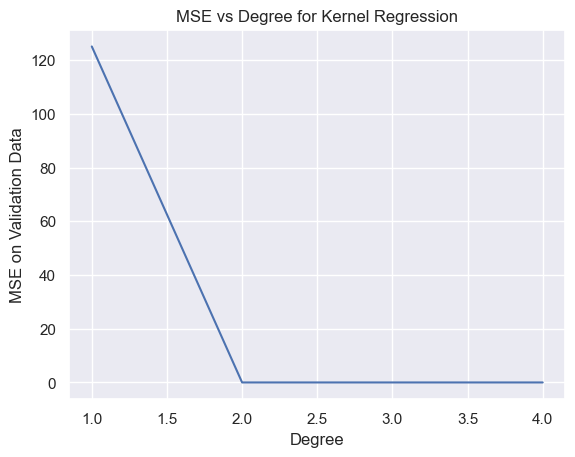

In [30]:
plt.plot(degrees, errors)
plt.xlabel('Degree')
plt.ylabel('MSE on Validation Data')
plt.title('MSE vs Degree for Kernel Regression')
plt.show()

In [31]:
kreg=KernelRegression(degree=2)
kreg.fit(X, y)

In [32]:
predictions=kreg.predict(X)
mse(y, predictions)

0.01006536308315977

In [33]:
predictions=kreg.predict(X_test)
mse(y_test, predictions)

0.009798525084448683